In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv('data/ecommerce_orders.csv')
df.head()

,订单号,订单日期,发货日期,客户ID,客户类型,区域,城市,品类,子品类,商品名称,...,数量,单价,销售额,折扣率,折扣金额,最终销售额,成本,利润,订单状态,评分
0,SO00100001,2024-04-12,2024-04-14,C00434,老客户,华南,佛山,数码,中端,耳机,...,6,3145.86,18875.16,0.00,0.00,18875.16,14393.12,4482.04,已完成,5.0
1,SO00100002,2025-03-11,2025-03-14,C00758,新客户,华南,东莞,家居,入门,窗帘,...,1,613.78,613.78,0.00,0.00,613.78,481.98,131.80,已完成,2.0
2,SO00100003,2024-09-27,2024-09-27,C00234,老客户,东北,大连,图书,中端,传记,...,1,103.81,103.81,0.00,0.00,103.81,41.54,62.27,已完成,3.0
3,SO00100004,2024-04-16,2024-04-21,C00670,老客户,华北,太原,家电,入门,电视,...,3,4937.04,14811.12,0.05,740.56,14070.56,8173.26,6637.86,已完成,4.0
4,SO00100005,2024-03-12,2024-03-12,C00663,老客户,华南,厦门,图书,高端,童书,...,1,107.83,107.83,0.00,0.00,107.83,76.39,31.44,已完成,4.0


In [3]:
df.info

<bound method DataFrame.info of              订单号        订单日期        发货日期    客户ID 客户类型  区域    城市  品类 子品类 商品名称  \
0     SO00100001  2024-04-12  2024-04-14  C00434  老客户  华南    佛山  数码  中端   耳机   
1     SO00100002  2025-03-11  2025-03-14  C00758  新客户  华南    东莞  家居  入门   窗帘   
2     SO00100003  2024-09-27  2024-09-27  C00234  老客户  东北    大连  图书  中端   传记   
3     SO00100004  2024-04-16  2024-04-21  C00670  老客户  华北    太原  家电  入门   电视   
4     SO00100005  2024-03-12  2024-03-12  C00663  老客户  华南    厦门  图书  高端   童书   
...          ...         ...         ...     ...  ...  ..   ...  ..  ..  ...   
9995  SO00109996  2024-05-05  2024-05-10  C00518  老客户  西北  乌鲁木齐  数码  中端   电脑   
9996  SO00109997  2024-11-01  2024-11-06  C00730  老客户  华南    广州  服饰  高端   裤子   
9997  SO00109998  2025-12-02  2025-12-04  C00027  新客户  华东    杭州  服饰  高端   外套   
9998  SO00109999  2025-05-25  2025-05-29  C00227  老客户  华南    厦门  家居  高端  装饰画   
9999  SO00110000  2024-03-29  2024-03-30  C00796  新客户  西南    南宁  服饰  中端   T恤   

      .

In [4]:
df.describe()

,数量,单价,销售额,折扣率,折扣金额,最终销售额,成本,利润,评分
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9782.000000
mean,1.969400,1479.352617,2936.557986,0.026275,80.433812,2856.124174,1836.779001,1099.778985,3.064915
std,1.594841,2007.033249,5630.513532,0.054260,394.360818,5489.799182,3612.480481,2269.775424,1.740435
min,1.000000,10.300000,10.300000,0.000000,0.000000,10.300000,4.890000,1.890000,0.000000
25%,1.000000,140.970000,212.210000,0.000000,0.000000,206.287500,131.510000,74.997500,2.000000
50%,1.000000,477.510000,710.250000,0.000000,0.000000,692.315000,433.215000,260.335000,4.000000
75%,3.000000,2170.812500,3274.285000,0.050000,2.395000,3204.705000,1964.300000,1140.232500,5.000000
max,8.000000,7999.940000,61453.600000,0.300000,11650.940000,61453.600000,51040.070000,34582.660000,5.000000


In [5]:
df.isnull().sum()

订单号        0
订单日期       0
发货日期       0
客户ID       0
客户类型       0
区域         0
城市        91
品类         0
子品类        0
商品名称       0
销售渠道       0
支付方式       0
数量         0
单价         0
销售额        0
折扣率        0
折扣金额       0
最终销售额      0
成本         0
利润         0
订单状态       0
评分       218
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates
print(len(df))
# 评分缺失值：用0填充（代表未评分）
df['评分'] = df['评分'].fillna(0)

# 城市缺失值：用"未知"填充
df['城市'] = df['城市'].fillna('未知')

# 确认没有缺失了
df.isnull().sum()

10000


订单号      0
订单日期     0
发货日期     0
客户ID     0
客户类型     0
区域       0
城市       0
品类       0
子品类      0
商品名称     0
销售渠道     0
支付方式     0
数量       0
单价       0
销售额      0
折扣率      0
折扣金额     0
最终销售额    0
成本       0
利润       0
订单状态     0
评分       0
dtype: int64

In [8]:
# 订单日期转日期类型
df['订单日期'] = pd.to_datetime(df['订单日期'])
df['发货日期'] = pd.to_datetime(df['发货日期'])

# 提取年月，方便后续做月度分析
df['年份'] = df['订单日期'].dt.year
df['月份'] = df['订单日期'].dt.month

In [9]:
# 只保留已完成的订单进行分析（退款/取消的不算正常销售）
df_clean = df[df['订单状态'] == '已完成'].copy()

print(f"清洗前: {len(df)} 行")
print(f"清洗后: {len(df_clean)} 行")
print(f"已完成订单占比: {len(df_clean)/len(df):.1%}")

清洗前: 10000 行
清洗后: 8544 行
已完成订单占比: 85.4%


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单号     10000 non-null  str           
 1   订单日期    10000 non-null  datetime64[us]
 2   发货日期    10000 non-null  datetime64[us]
 3   客户ID    10000 non-null  str           
 4   客户类型    10000 non-null  str           
 5   区域      10000 non-null  str           
 6   城市      10000 non-null  str           
 7   品类      10000 non-null  str           
 8   子品类     10000 non-null  str           
 9   商品名称    10000 non-null  str           
 10  销售渠道    10000 non-null  str           
 11  支付方式    10000 non-null  str           
 12  数量      10000 non-null  int64         
 13  单价      10000 non-null  float64       
 14  销售额     10000 non-null  float64       
 15  折扣率     10000 non-null  float64       
 16  折扣金额    10000 non-null  float64       
 17  最终销售额   10000 non-null  float64       
 18  成本      10000 non-

In [11]:
# 核心指标
total_sales = df['最终销售额'].sum()
total_profit = df['利润'].sum()
total_orders = df['订单号'].nunique()
avg_order_value = df['最终销售额'].sum() / total_orders

print(f"总销售额: {total_sales:,.0f} 元")
print(f"总利润: {total_profit:,.0f} 元")
print(f"总订单数: {total_orders}")
print(f"平均客单价: {avg_order_value:,.0f} 元")
print(f"整体利润率: {total_profit/total_sales:.1%}")

总销售额: 28,561,242 元
总利润: 10,997,790 元
总订单数: 10000
平均客单价: 2,856 元
整体利润率: 38.5%


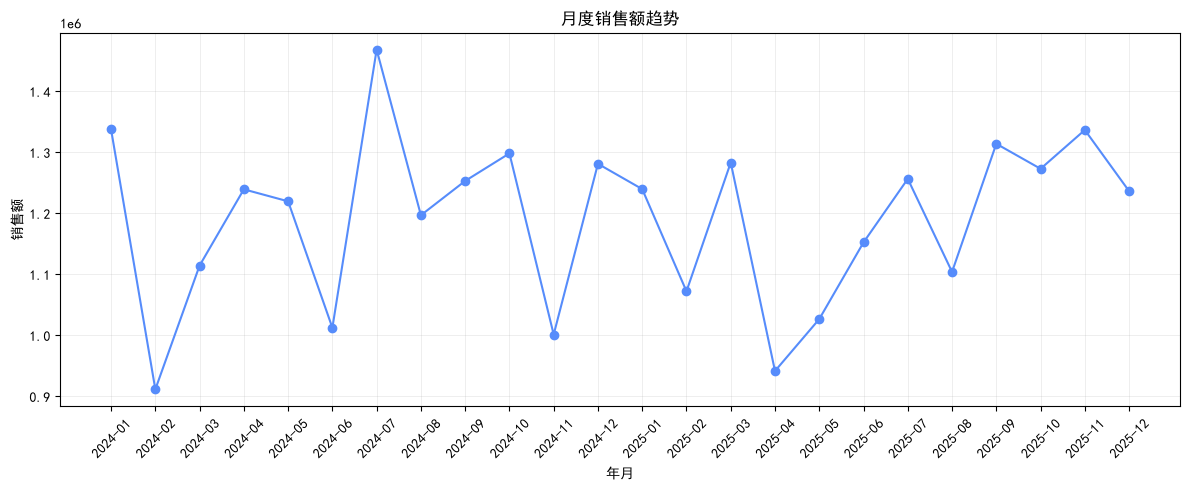

In [12]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams[ 'font.sans-serif' ] = [ 'SimHei' ]

# 按年月汇总
monthly = df.groupby(['年份', '月份'])['最终销售额'].sum().reset_index()
monthly['年月'] = monthly['年份'].astype(str) + '-' + monthly['月份'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(monthly['年月'], monthly['最终销售额'], marker='o')
plt.title('月度销售额趋势')
plt.xlabel('年月')
plt.ylabel('销售额')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

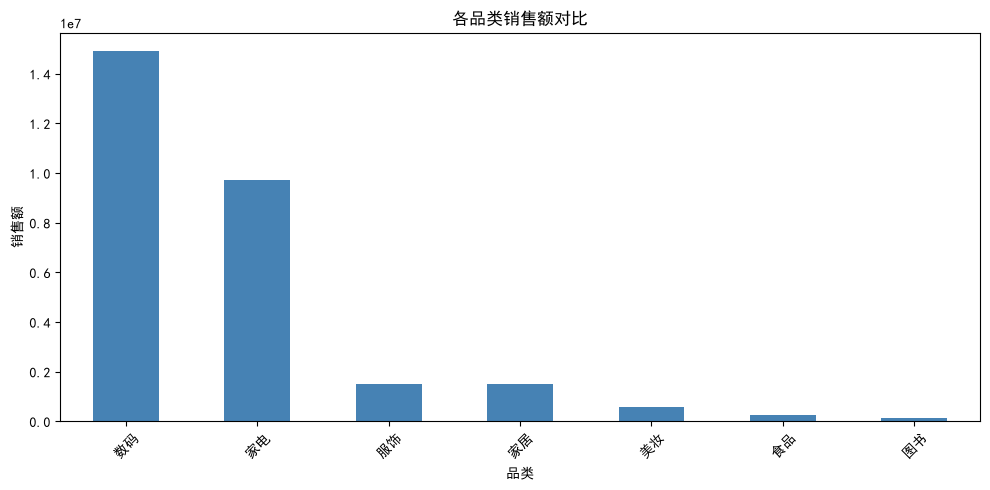

In [13]:
category_sales = df.groupby('品类')['最终销售额'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.plot(kind='bar', color='steelblue')
plt.title('各品类销售额对比')
plt.xlabel('品类')
plt.ylabel('销售额')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

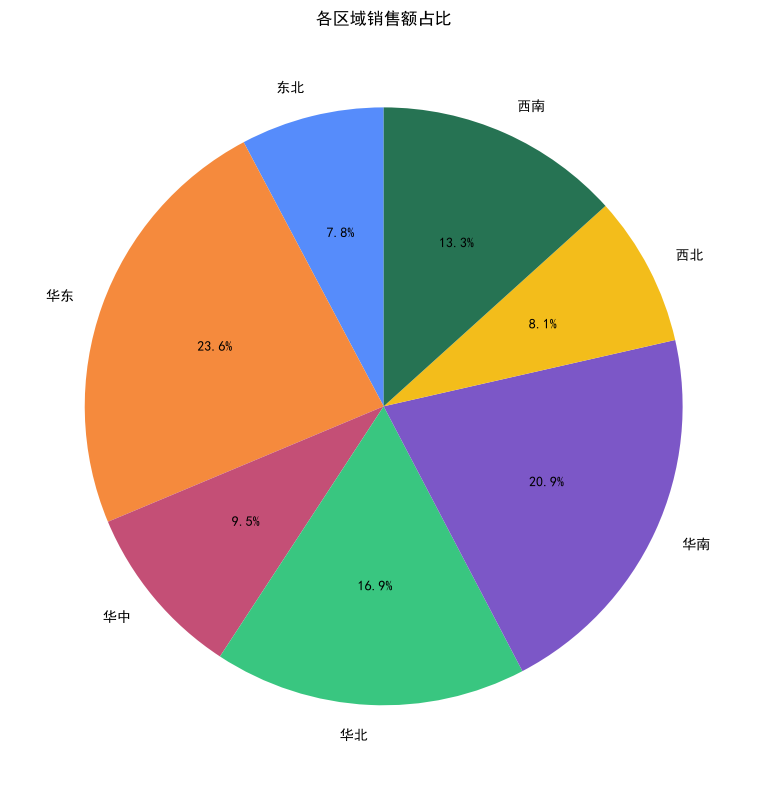

In [14]:
region_sales = df.groupby('区域')['最终销售额'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('各区域销售额占比')
plt.tight_layout()
plt.show()

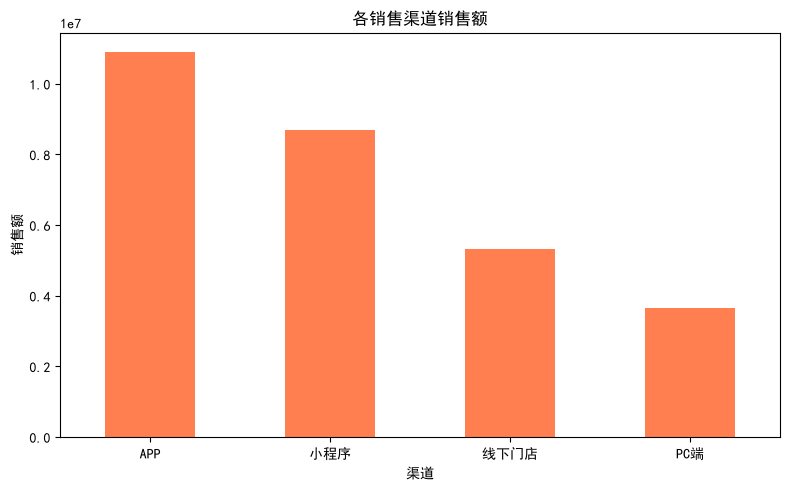

In [15]:
channel_sales = df.groupby('销售渠道')['最终销售额'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
channel_sales.plot(kind='bar', color='coral')
plt.title('各销售渠道销售额')
plt.xlabel('渠道')
plt.ylabel('销售额')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

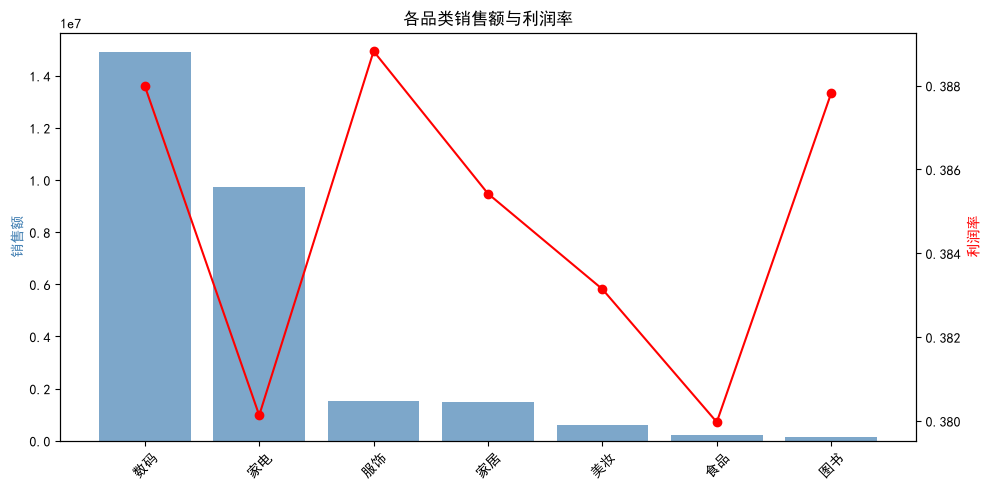

In [17]:
category_profit = df.groupby('品类').agg(
    销售额=('最终销售额', 'sum'),
    利润=('利润', 'sum')
).sort_values('销售额', ascending=False)
category_profit['利润率'] = category_profit['利润'] / category_profit['销售额']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(category_profit.index, category_profit['销售额'], color='steelblue', alpha=0.7, label='销售额')
ax1.set_ylabel('销售额', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(category_profit.index, category_profit['利润率'], color='red', marker='o', label='利润率')
ax2.set_ylabel('利润率', color='red')

plt.title('各品类销售额与利润率')
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取数据
df = pd.read_csv('data/ecommerce_orders.csv')

# 2. 数据清洗
df['评分'] = df['评分'].fillna(0)
df['城市'] = df['城市'].fillna('未知')
df['订单日期'] = pd.to_datetime(df['订单日期'])
df['发货日期'] = pd.to_datetime(df['发货日期'])
df['年份'] = df['订单日期'].dt.year
df['月份'] = df['订单日期'].dt.month
df = df[df['订单状态'] == '已完成'].copy()

# ===== 业务问题1：各品类利润排名 =====
category_analysis = df.groupby('品类').agg(
    销售额=('最终销售额', 'sum'),
    利润=('利润', 'sum'),
    订单数=('订单号', 'count')
).sort_values('利润', ascending=False)
category_analysis['利润率'] = category_analysis['利润'] / category_analysis['销售额']
category_analysis['利润占比'] = category_analysis['利润'] / category_analysis['利润'].sum()

print("=" * 50)
print("业务问题1：各品类利润排名")
print("=" * 50)
print(category_analysis[['销售额', '利润', '利润率', '利润占比']].round(2))
print()

# ===== 业务问题2：各区域同比增长 =====
region_year = df.groupby(['区域', '年份'])['最终销售额'].sum().unstack()
region_year['增长率'] = (region_year[2025] - region_year[2024]) / region_year[2024]
region_year = region_year.sort_values('增长率', ascending=False)

print("=" * 50)
print("业务问题2：各区域 2024 vs 2025 销售额及增长率")
print("=" * 50)
print(region_year.round(2))
print()

# ===== 业务问题3：客户分层（RFM） =====
max_date = df['订单日期'].max()
rfm = df.groupby('客户ID').agg({
    '订单日期': lambda x: (max_date - x.max()).days,
    '订单号': 'count',
    '最终销售额': 'sum'
}).rename(columns={'订单日期': 'R', '订单号': 'F', '最终销售额': 'M'})

rfm['R_score'] = pd.qcut(rfm['R'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

def rfm_label(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return '重要价值客户'
    elif r >= 4 and f < 4 and m >= 4:
        return '重要发展客户'
    elif r < 4 and f >= 4 and m >= 4:
        return '重要保持客户'
    elif r < 4 and f < 4 and m >= 4:
        return '重要挽留客户'
    else:
        return '一般客户'

rfm['客户分层'] = rfm.apply(rfm_label, axis=1)
segment_counts = rfm['客户分层'].value_counts()

print("=" * 50)
print("业务问题3：客户分层统计")
print("=" * 50)
print(segment_counts)

业务问题1：各品类利润排名
            销售额          利润   利润率  利润占比
品类                                     
数码  12786248.50  4971745.53  0.39  0.53
家电   8062672.19  3041672.58  0.38  0.33
服饰   1274493.67   493978.31  0.39  0.05
家居   1267796.16   489450.32  0.39  0.05
美妆    495203.91   188168.14  0.38  0.02
食品    196082.63    74372.82  0.38  0.01
图书    110064.99    42753.45  0.39  0.00

业务问题2：各区域 2024 vs 2025 销售额及增长率
年份        2024        2025   增长率
区域                              
华南  2343780.08  2768320.94  0.18
华东  2743352.15  3001697.70  0.09
华北  2061975.09  1988967.86 -0.04
西南  1702827.48  1533877.40 -0.10
东北   999450.90   882582.56 -0.12
华中  1202165.13  1044644.60 -0.13
西北  1035225.26   883694.90 -0.15

业务问题3：客户分层统计
客户分层
一般客户      479
重要价值客户    105
重要挽留客户     87
重要保持客户     83
重要发展客户     45
Name: count, dtype: int64
